In [4]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [5]:
# load dataset
df = pd.read_csv(r"Exam dataset\website.csv",
                 delimiter=",")
df

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0
...,...,...,...,...,...,...,...
1995,1,2.724513,0.207187,Referral,1.324206,2,1.0
1996,3,0.392856,0.095559,Organic,3.824416,1,1.0
1997,4,9.899823,0.446622,Organic,1.288675,1,1.0
1998,3,0.393319,0.278340,Paid,5.037584,2,1.0


In [6]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 non-null   float64
 2   Bounce Rate       2000 non-null   float64
 3   Traffic Source    2000 non-null   object 
 4   Time on Page      2000 non-null   float64
 5   Previous Visits   2000 non-null   int64  
 6   Conversion Rate   2000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 109.5+ KB


In [7]:
# summary of statistics
df.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Conversion Rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,0.982065
std,2.183903,3.104518,0.159781,2.887422,1.432852,0.065680
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.343665
25%,3.000000,0.815828,0.161986,1.935037,1.000000,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000,1.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000,1.000000


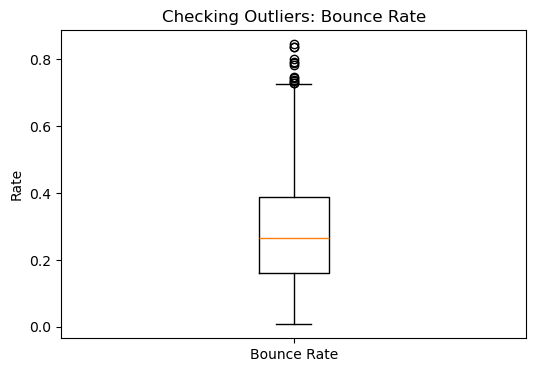

In [8]:
# plotting Bounce Rate
plt.figure(figsize=(6, 4))
plt.boxplot(df['Bounce Rate'], tick_labels=['Bounce Rate'])
plt.title("Checking Outliers: Bounce Rate")
plt.ylabel("Rate")
plt.show()

In [9]:
# removing bounce rate outliers
z_bounce = stats.zscore(df['Bounce Rate'])
bounce_outliers = (z_bounce < -3) | (z_bounce > 3)
df = df[~bounce_outliers]

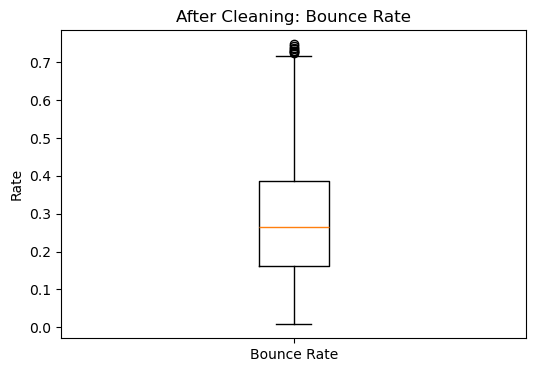

Dataset size after removing outliers: 1993 rows


In [10]:
# re-plot clean Bounce Rate
plt.figure(figsize=(6, 4))
plt.boxplot(df['Bounce Rate'], tick_labels=['Bounce Rate'])
plt.title("After Cleaning: Bounce Rate")
plt.ylabel("Rate")
plt.show()

print(f"Dataset size after removing outliers: {df.shape[0]} rows")

In [11]:
np.random.seed(42)
n_samples = 100
sample_size = 30

bounce_means = []

for _ in range(n_samples):
    bounce_means.append(df['Bounce Rate'].sample(sample_size, replace=True).mean())

# normalized dataframe of the sample means
clt_df = pd.DataFrame({
    'Bounce_Means': bounce_means
})

print(clt_df.describe())

       Bounce_Means
count    100.000000
mean       0.278184
std        0.025935
min        0.217350
25%        0.258747
50%        0.276909
75%        0.294456
max        0.362882


1-SAMPLE T-TEST

In [12]:
"""
two-tailed test
------------------
Ho: u_bounce = 0.50
Ha: u_bounce != 0.50 
"""
#standard bounce rate standard
pop_mean = 0.50

# bounce means from our CLT-normalized dataframe
t_test, p_value = stats.ttest_1samp(clt_df['Bounce_Means'], pop_mean,
                                    alternative='two-sided')

print(f"t statistic: {t_test:.4f}")
print(f"P-value: {p_value:.4f}")

t statistic: -85.5268
P-value: 0.0000


In [13]:
# cohen's d
# For 1-sample, we compare the sample mean to the population mean
sample_mean = clt_df['Bounce_Means'].mean()
sample_std = clt_df['Bounce_Means'].std(ddof=1)
pop_mean = 0.50

d = abs((sample_mean - pop_mean) / sample_std)

print(f"Cohen's d: {d:.4f}")

Cohen's d: 8.5527


In [14]:
# power of a test
power = TTestPower().power(
    effect_size = d, 
    nobs = clt_df['Bounce_Means'].count(),
    alpha = 0.05,
    alternative = "two-sided"
)

print(f"Power of the test: {power*100:.2f}%")

Power of the test: 100.00%
